In [40]:
import mitgcm_assim.cost as cost

# Read all costfunction* files in current directory
ds_sep = cost.read_costfunction('/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_ad/')
ds_nov = cost.read_costfunction('/data/SO3/edavenport/tpose6/nov2012/run_ad_withGLD/')
ds_jan = cost.read_costfunction('/data/SO3/edavenport/tpose6/jan2013/run_ad/')
ds_mar = cost.read_costfunction('/data/SO3/edavenport/tpose6/mar2013/run_ad/')

In [41]:
# Identify the coordinate values that start with 'xx'
to_drop = [val for val in ds_mar.dataset.values if str(val).startswith('xx')]

# Drop those specific coordinates
ds_mar = ds_mar.drop_sel(dataset=to_drop)
ds_sep = ds_sep.drop_sel(dataset=to_drop)
ds_nov = ds_nov.drop_sel(dataset=to_drop)
ds_jan = ds_jan.drop_sel(dataset=to_drop)

# 1. Create a mask: True for anything that does NOT contain "GLD"
mask = ~ds_mar.dataset.str.contains("GLD")
# 2. Apply the mask to the dataset
ds_mar = ds_mar.sel(dataset=mask)
mask = ~ds_sep.dataset.str.contains("GLD")
ds_sep = ds_sep.sel(dataset=mask)
mask = ~ds_nov.dataset.str.contains("GLD")
ds_nov = ds_nov.sel(dataset=mask)
mask = ~ds_jan.dataset.str.contains("GLD")
ds_jan = ds_jan.sel(dataset=mask)

ds_mar = ds_mar.drop_sel(dataset='fc')
ds_sep = ds_sep.drop_sel(dataset='fc')
ds_nov = ds_nov.drop_sel(dataset='fc')
ds_jan = ds_jan.drop_sel(dataset='fc')

ds_mar = ds_mar.drop_sel(dataset=['sshv4-gfo','sshv4-mdt'])
ds_sep = ds_sep.drop_sel(dataset=['sshv4-gfo','sshv4-mdt'])
ds_nov = ds_nov.drop_sel(dataset=['sshv4-gfo','sshv4-mdt'])
ds_jan = ds_jan.drop_sel(dataset=['sshv4-gfo','sshv4-mdt'])

In [42]:
import re

# 1. Define a function to strip the year (e.g., _2013_)
def remove_year(name):
    # This looks for an underscore, 4 digits, and another underscore
    return re.sub(r'_\d{4}_', '_', str(name))

# 3. Assign the cleaned names back and group duplicates
# We use .groupby('dataset').sum() in case stripping the year 
# results in multiple entries with the same name.
new_coords = [remove_year(val) for val in ds_mar.dataset.values]
ds_mar = ds_mar.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_year(val) for val in ds_sep.dataset.values]
ds_sep = ds_sep.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_year(val) for val in ds_nov.dataset.values]
ds_nov = ds_nov.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_year(val) for val in ds_jan.dataset.values]
ds_jan = ds_jan.assign_coords(dataset=new_coords).groupby('dataset').sum()

def remove_v2(name):
    return re.sub(r'_v2_', '_', str(name))

# 3. Assign the cleaned names back and group duplicates
# We use .groupby('dataset').sum() in case stripping the year 
# results in multiple entries with the same name.
new_coords = [remove_v2(val) for val in ds_mar.dataset.values]
ds_mar = ds_mar.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_v2(val) for val in ds_sep.dataset.values]
ds_sep = ds_sep.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_v2(val) for val in ds_nov.dataset.values]
ds_nov = ds_nov.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_v2(val) for val in ds_jan.dataset.values]
ds_jan = ds_jan.assign_coords(dataset=new_coords).groupby('dataset').sum()

def remove_ED(name):
    return re.sub(r'_ED_', '_', str(name))

# 3. Assign the cleaned names back and group duplicates
# We use .groupby('dataset').sum() in case stripping the year 
# results in multiple entries with the same name.
new_coords = [remove_ED(val) for val in ds_mar.dataset.values]
ds_mar = ds_mar.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_ED(val) for val in ds_sep.dataset.values]
ds_sep = ds_sep.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_ED(val) for val in ds_nov.dataset.values]
ds_nov = ds_nov.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_ED(val) for val in ds_jan.dataset.values]
ds_jan = ds_jan.assign_coords(dataset=new_coords).groupby('dataset').sum()

In [43]:
rename_map = {
    'TAO_WO_CTD_daily_prof_S': 'TAO/TRITON S',
    'TAO_WO_CTD_daily_prof_T': 'TAO/TRITON T',
    'TAO_WO_ADCP_prof_U': 'TAO/TRITON ADCP U',
    'TAO_WO_ADCP_prof_V': 'TAO/TRITON ADCP V',
    'TAO_WO_CUR_prof_U': 'TAO/TRITON CUR U',
    'TAO_WO_CUR_prof_V': 'TAO/TRITON CUR V',
    'USGO_TP_PFL_D_w_prof_S': 'Argo S',
    'USGO_TP_PFL_D_w_prof_T': 'Argo T',
    'WOD_TP_XBT_w_prof_T': 'WOD XBT T',
    'HDO_TP_CTD_w_prof_S': 'CTD S',
    'HDO_TP_CTD_w_prof_T': 'CTD T',
    'SIO_TP_XBT_w_prof_T': 'SIO XBT T',
    'sst-MW':'SST',
    'sshv4-tp':'SSH',
    # 'sshv4-gfo':'SSH Cryosat',
    # 'sshv4-mdt':'Geoid'
}
ds_mar = ds_mar.assign_coords(
    dataset=ds_mar.dataset.to_index().map(lambda x: rename_map.get(x, x))
)
ds_jan = ds_jan.assign_coords(
    dataset=ds_jan.dataset.to_index().map(lambda x: rename_map.get(x, x))
)
ds_sep = ds_sep.assign_coords(
    dataset=ds_sep.dataset.to_index().map(lambda x: rename_map.get(x, x))
)
ds_nov = ds_nov.assign_coords(
    dataset=ds_nov.dataset.to_index().map(lambda x: rename_map.get(x, x))
)

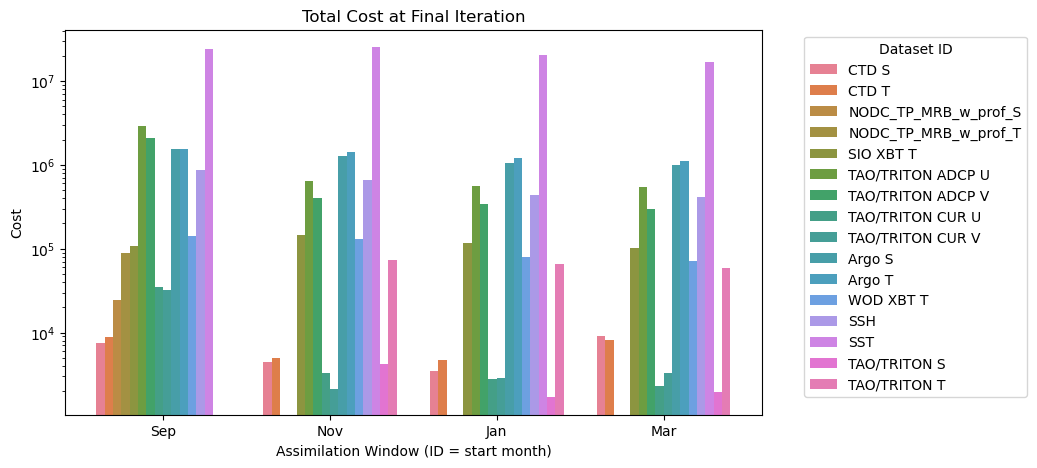

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a dictionary of the datasets
datasets = {
    'Sep': ds_sep,
    'Nov': ds_nov,
    'Jan': ds_jan,
    'Mar': ds_mar
}


df_list = []

for label, ds in datasets.items():
    # 2. Select the last iteration if the 'iter' dimension still exists
    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=-1)
    else:
        ds_subset = ds
    
    # 3. Convert only the 'cost' variable to a DataFrame
    # This automatically uses the 'dataset' coordinate as an index
    df = ds_subset[['cost']].to_dataframe().reset_index()
    
    # 4. Add a column to identify which group (month) this data belongs to
    df['Group'] = label
    
    df_list.append(df)

# 5. Combine all dataframes into one
df_total = pd.concat(df_list, ignore_index=True)

# 6. Plot using Seaborn
fig = plt.figure(figsize=(9, 5))
sns.barplot(data=df_total, x='Group', y='cost', hue='dataset')

plt.title('Total Cost at Final Iteration')
plt.xlabel('Assimilation Window (ID = start month)')
plt.ylabel('Cost')
plt.semilogy()
plt.legend(title='Dataset ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
fig.savefig('assimilation_results/normalized_cost/cost.png')

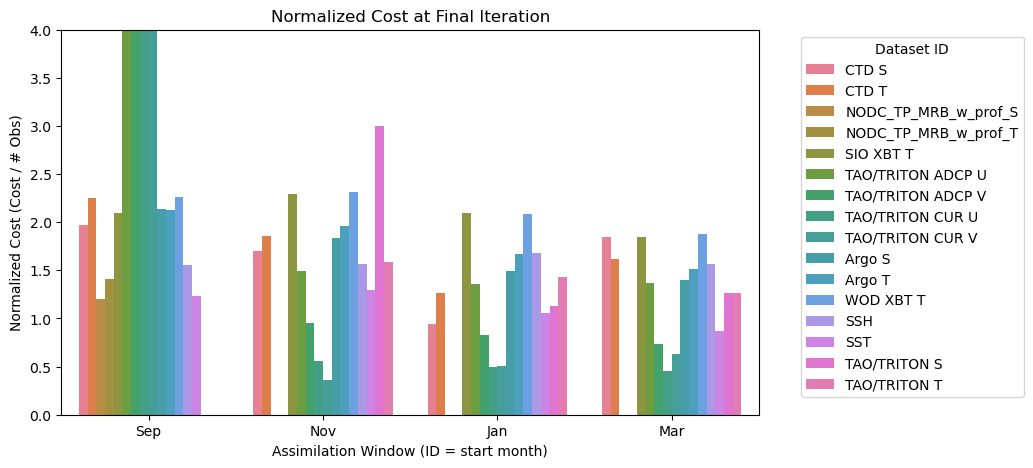

In [34]:
datasets = {
    'Sep': ds_sep,
    'Nov': ds_nov,
    'Jan': ds_jan,
    'Mar': ds_mar
}

df_list = []

for label, ds in datasets.items():
    # 1. Select the last iteration
    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=-1)
    else:
        ds_subset = ds
    
    # 2. Calculate normalized cost 
    ds_subset['norm_cost'] = ds_subset['cost'] / ds_subset['n_obs']
    
    # 3. Convert to DataFrame (include the new variable)
    df = ds_subset[['norm_cost']].to_dataframe().reset_index()
    df['Group'] = label
    
    df_list.append(df)

# 4. Combine
df_total = pd.concat(df_list, ignore_index=True)

# 5. Plot
fig = plt.figure(figsize=(9, 5))
sns.barplot(data=df_total, x='Group', y='norm_cost', hue='dataset')

plt.title('Normalized Cost at Final Iteration')
plt.xlabel('Assimilation Window (ID = start month)')
plt.ylabel('Normalized Cost (Cost / # Obs)')
plt.ylim(0,4)
plt.legend(title='Dataset ID', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
plt.show()

fig.savefig('assimilation_results/normalized_cost/normalized_cost.png')

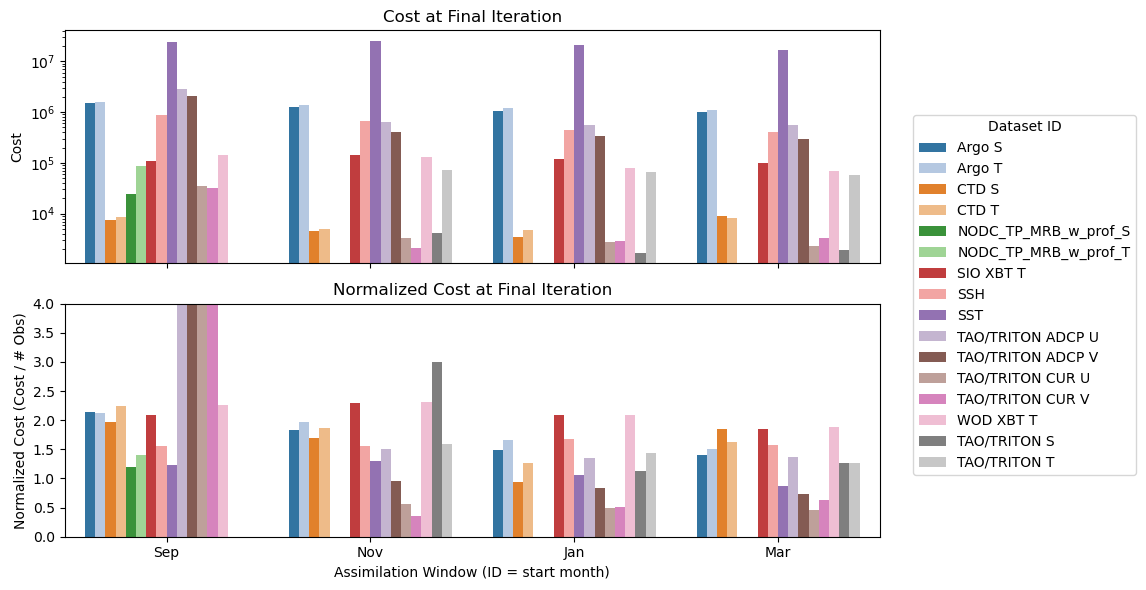

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

datasets = {
    'Sep': ds_sep,
    'Nov': ds_nov,
    'Jan': ds_jan,
    'Mar': ds_mar
}

df_list_cost = []
df_list_norm = []

for label, ds in datasets.items():
    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=-1)
    else:
        ds_subset = ds

    df_cost = ds_subset[['cost']].to_dataframe().reset_index()
    df_cost['Group'] = label
    df_list_cost.append(df_cost)

    ds_subset['norm_cost'] = ds_subset['cost'] / ds_subset['n_obs']
    df_norm = ds_subset[['norm_cost']].to_dataframe().reset_index()
    df_norm['Group'] = label
    df_list_norm.append(df_norm)

df_cost_total = pd.concat(df_list_cost, ignore_index=True)
df_norm_total = pd.concat(df_list_norm, ignore_index=True)

# Lock x-axis order, sort hue alphabetically within each group
group_order = ['Sep', 'Nov', 'Jan', 'Mar']

df_cost_total['Group'] = pd.Categorical(df_cost_total['Group'], categories=group_order, ordered=True)
df_norm_total['Group'] = pd.Categorical(df_norm_total['Group'], categories=group_order, ordered=True)

df_cost_total = df_cost_total.sort_values(['Group', 'dataset']).reset_index(drop=True)
df_norm_total = df_norm_total.sort_values(['Group', 'dataset']).reset_index(drop=True)
hue_order = sorted(df_cost_total['dataset'].unique())

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

sns.barplot(data=df_cost_total, x='Group', y='cost', hue='dataset', hue_order=hue_order, ax=ax_top, legend=False, palette='tab20')
ax_top.set_yscale('log')
ax_top.set_title('Cost at Final Iteration')
ax_top.set_xlabel('')
ax_top.set_ylabel('Cost')

sns.barplot(data=df_norm_total, x='Group', y='norm_cost', hue='dataset', hue_order=hue_order, ax=ax_bot, legend=True, palette='tab20')
ax_bot.set_title('Normalized Cost at Final Iteration')
ax_bot.set_xlabel('Assimilation Window (ID = start month)')
ax_bot.set_ylabel('Normalized Cost (Cost / # Obs)')
ax_bot.set_ylim(0, 4)

handles, labels = ax_bot.get_legend_handles_labels()
ax_bot.get_legend().remove()
fig.legend(handles, labels, title='Dataset ID',
           bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)

plt.tight_layout()
fig.savefig('assimilation_results/normalized_cost/cost_normcost_tab20.png', bbox_inches='tight')
plt.show()

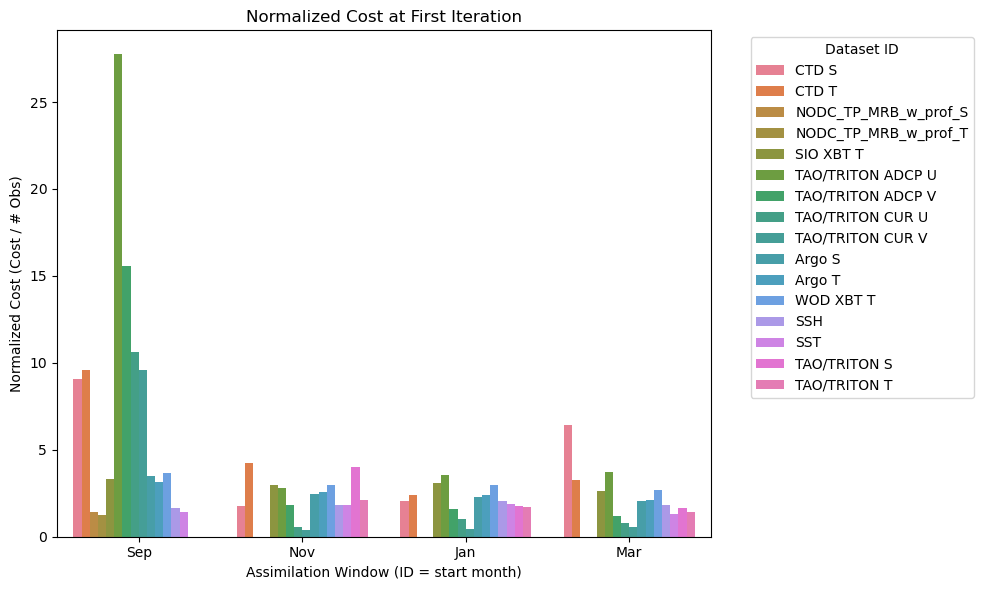

In [7]:
datasets = {
    'Sep': ds_sep,
    'Nov': ds_nov,
    'Jan': ds_jan,
    'Mar': ds_mar
}

df_list = []

for label, ds in datasets.items():
    # 1. Select the last iteration
    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=0)
    else:
        ds_subset = ds
    
    # 2. Calculate normalized cost 
    ds_subset['norm_cost'] = ds_subset['cost'] / ds_subset['n_obs']
    
    # 3. Convert to DataFrame (include the new variable)
    df = ds_subset[['norm_cost']].to_dataframe().reset_index()
    df['Group'] = label
    
    df_list.append(df)

# 4. Combine
df_total = pd.concat(df_list, ignore_index=True)

# 5. Plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(data=df_total, x='Group', y='norm_cost', hue='dataset')
plt.title('Normalized Cost at First Iteration')
plt.xlabel('Assimilation Window (ID = start month)')
plt.ylabel('Normalized Cost (Cost / # Obs)')
plt.legend(title='Dataset ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

fig.savefig('assimilation_results/normalized_cost/normalized_cost_iter0.png')

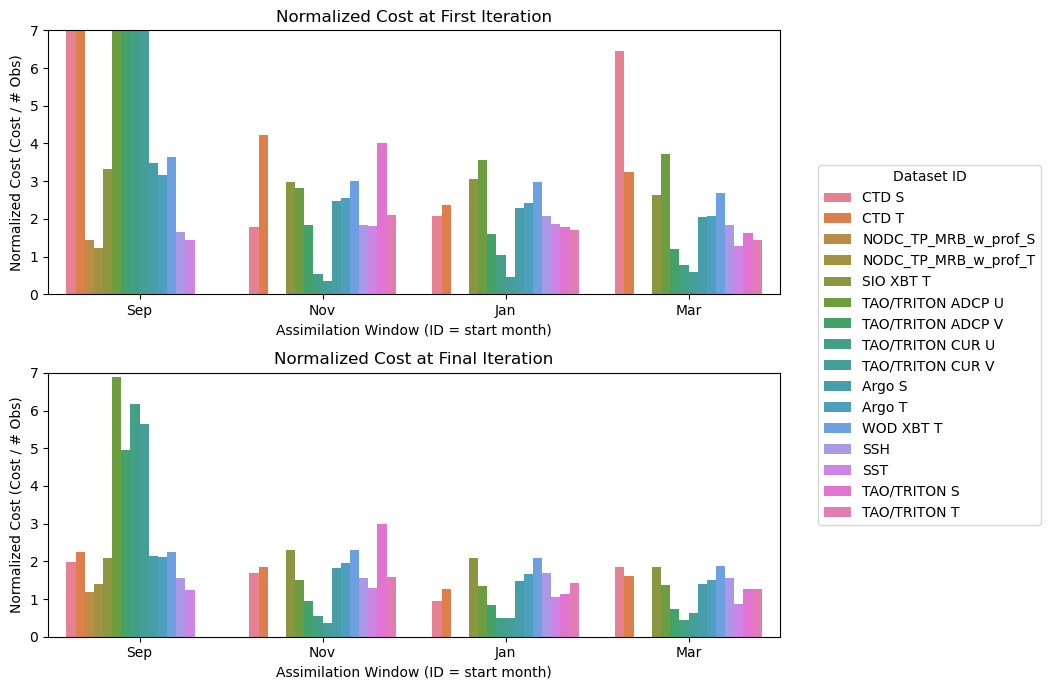

In [8]:
datasets = {
    'Sep': ds_sep,
    'Nov': ds_nov,
    'Jan': ds_jan,
    'Mar': ds_mar
}

iterations = {
    'First Iteration': 0,
    'Final Iteration': -1
}

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 7))

for ax, (title_label, iter_idx) in zip(axes, iterations.items()):
    df_list = []

    for label, ds in datasets.items():
        if 'iter' in ds.dims:
            ds_subset = ds.isel(iter=iter_idx)
        else:
            ds_subset = ds

        ds_subset['norm_cost'] = ds_subset['cost'] / ds_subset['n_obs']

        df = ds_subset[['norm_cost']].to_dataframe().reset_index()
        df['Group'] = label
        df_list.append(df)

    df_total = pd.concat(df_list, ignore_index=True)

    sns.barplot(data=df_total, x='Group', y='norm_cost', hue='dataset', ax=ax)
    ax.set_title(f'Normalized Cost at {title_label}')
    ax.set_xlabel('Assimilation Window (ID = start month)')
    ax.set_ylim(0,7)
    ax.set_ylabel('Normalized Cost (Cost / # Obs)')
    ax.get_legend().remove()

# Add a single legend from the last axis
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Dataset ID', bbox_to_anchor=(1.02, 0.5), loc='center left')

plt.tight_layout()
plt.savefig('assimilation_results/normalized_cost/normalized_cost_combined.png', bbox_inches='tight')
plt.show()